<a href="https://colab.research.google.com/github/AnisleyPovea/ADSI/blob/main/Copia_de_Notebook_Actividad_S01.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

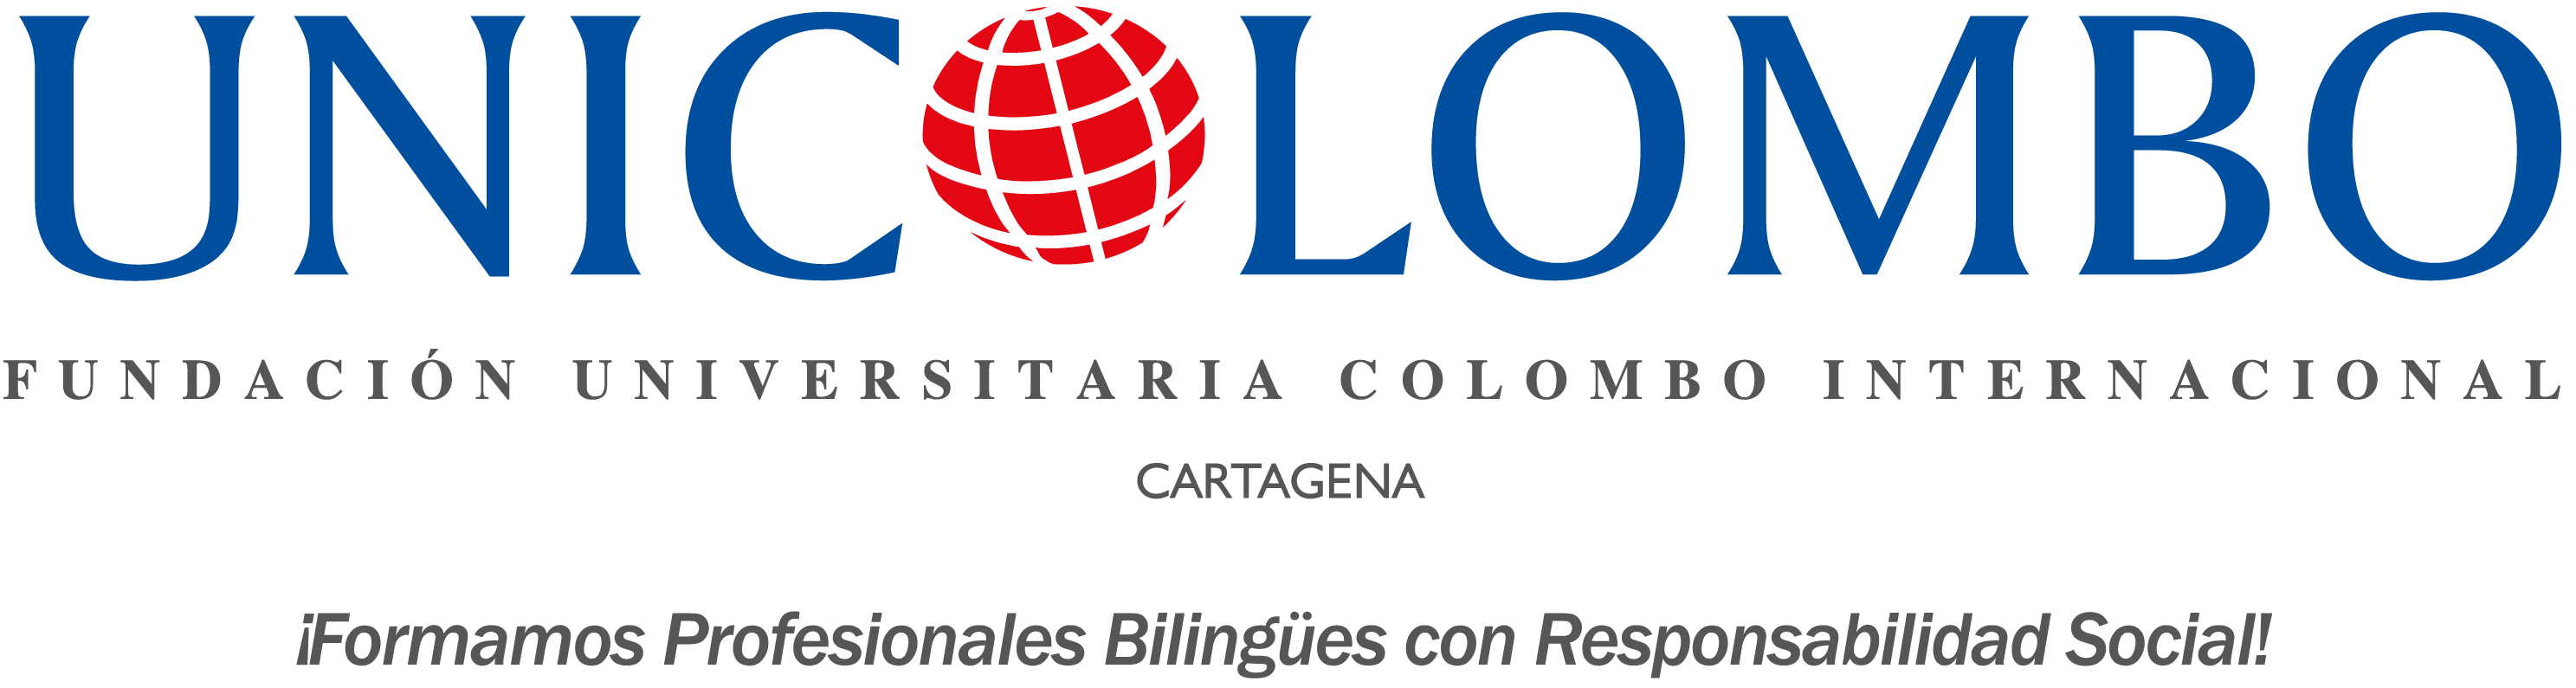

# Diplomado de Grado en Análisis de Datos Aplicado a la Toma de Decisiones
## UNICOLOMBO — Fundación Universitaria Colombo Internacional · Cartagena
**Módulo 2:** Preparación y Análisis Exploratorio de Datos  
**Sesión 1:** Diagnóstico y Calidad de Datos  
**Docente:** Ing. Heyder Medrano Olier  
**Período:** 2026 — Vacaciones

---
**Tipo:** Notebook de Actividad (trabajo del estudiante)  
**Entrega:** 27 de junio de 2026 · 23:59 (hora Colombia)  
**Valor:** 5.0 puntos  

> ⚠️ **Antes de entregar:** Ejecute *Kernel → Restart & Run All* para confirmar que todo corre sin errores.

**Estudiante:** [escriba su nombre completo aquí]  
**Fecha de ejecución:** [escriba la fecha aquí]

## Contexto

El CTO de **DataRetail LATAM S.A.S.** le ha encargado auditar la calidad de los datos de ventas. Usará el mismo dataset sintético visto en clase. Su análisis determinará si los datos son confiables para tomar decisiones presupuestarias del próximo trimestre.

In [1]:
!pip install ydata-profiling

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 400.8/400.8 kB 8.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 296.7/296.7 kB 16.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 58.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 679.7/679.7 kB 35.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 105.4/105.4 kB 6.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.0/72.0 kB 5.1 MB/s eta 0:00:00


In [2]:
from ydata_profiling import ProfileReport

/tmp/ipykernel_5982/44057814.py:1: DeprecationWarning: 
    `import ydata_profiling` is deprecated and will not receive more updates. 
    Please install fg-data-profiling via `pip install fg-data-profiling` and use `import data_profiling` instead.
    
  from ydata_profiling import ProfileReport


In [10]:
profile = ProfileReport(
    df,
    title="Reporte Calidad de Datos",
    explorative=True
)

## Parte 1 — Configuración

In [5]:
# Instalar si es necesario: !pip install ydata-profiling dtale missingno scipy
import pandas as pd, numpy as np
import matplotlib.pyplot as plt, seaborn as sns
import missingno as msno, scipy.stats as stats, warnings

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.max_columns', 20)
print('✅ Librerías listas')

✅ Librerías listas


## Parte 2 — Generación del Dataset

Ejecute esta celda sin modificar. Genera el dataset DataRetail LATAM con problemas de calidad intencionales.

In [7]:
import numpy as np, pandas as pd, random
from datetime import datetime, timedelta

np.random.seed(42); random.seed(42)
N = 2000

ciudades = ['Bogotá','Medellín','Cali','Barranquilla','Cartagena',
            'Lima','Ciudad de México','Buenos Aires','Santiago','Montevideo']
# Versiones con inconsistencias intencionales
ciudades_sucias = ciudades + ['bogota','BOGOTÁ','Medellin','cali ','barranquilla',
                               'Ciudad de mexico','buenos aires','SANTIAGO']
paises   = ['Colombia','Perú','México','Argentina','Chile','Uruguay']
categorias = ['Computación','Periféricos','Audio','Telefonía','Accesorios','Gaming','Componentes']
canales  = ['Tienda Física','E-commerce','Distribuidor','Corporativo','Marketplace']
# Versiones sucias de canal
canales_sucios = canales + ['tienda fisica','E-Comerce','distribuidor ','CORPORATIVO']
productos = ['Laptop Pro','Tablet Ultra','Monitor 4K','Teclado Inalámbrico',
             'Auriculares BT','Parlante Portátil','Smartphone Galaxy',
             'Cámara Web HD','Smartwatch Pro','Mouse Gaming','SSD 1TB','GPU RTX 4060']
precios_base = {'Laptop Pro':1200,'Tablet Ultra':450,'Monitor 4K':380,
                'Teclado Inalámbrico':75,'Auriculares BT':120,'Parlante Portátil':90,
                'Smartphone Galaxy':680,'Cámara Web HD':95,'Smartwatch Pro':250,
                'Mouse Gaming':65,'SSD 1TB':130,'GPU RTX 4060':580}

rows = []
for i in range(N):
    prod  = random.choice(productos)
    cat   = categorias[productos.index(prod) % len(categorias)]
    pais  = random.choice(paises)
    # ciudad con inconsistencias (15% de registros)
    if random.random() < 0.15:
        ciudad = random.choice(ciudades_sucias)
    else:
        ciudad = random.choice(ciudades)
    # canal con inconsistencias (10% de registros)
    canal = random.choice(canales_sucios) if random.random() < 0.10 else random.choice(canales)
    qty   = random.randint(1, 20)
    precio= round(precios_base[prod] * np.random.uniform(0.8,1.3), 2)
    desc  = round(random.choice([0,0,0,0.05,0.10,0.15,0.20,0.30,
                                  0.35,0.50]), 2)  # algunos > 30% (violación)
    total = round(qty * precio * (1 - desc), 2)
    margen= round(total * np.random.uniform(-0.05, 0.35), 2)
    fecha = datetime(2024,1,1) + timedelta(days=random.randint(0,729))
    rows.append({
        'id_venta':       f'V{i+1:05d}',
        'fecha_venta':    fecha.strftime('%Y-%m-%d'),
        'id_cliente':     f'C{random.randint(1,500):04d}',
        'nombre_cliente': f'Cliente {random.randint(1,500)}',
        'ciudad':         ciudad,
        'pais':           pais,
        'id_producto':    f'P{productos.index(prod)+1:02d}',
        'nombre_producto':prod,
        'categoria':      cat,
        'canal_venta':    canal,
        'cantidad':       qty,
        'precio_unitario':precio,
        'descuento':      desc,
        'total_venta':    total,
        'margen_utilidad':margen,
    })

df_raw = pd.DataFrame(rows)

# ── Introducir problemas de calidad intencionales ──────────────────────────
# 1. Nulos (~6% en precio_unitario, ~4% en total_venta, ~3% en margen_utilidad)
idx_p = np.random.choice(df_raw.index, size=int(N*0.06), replace=False)
idx_t = np.random.choice(df_raw.index, size=int(N*0.04), replace=False)
idx_m = np.random.choice(df_raw.index, size=int(N*0.03), replace=False)
df_raw.loc[idx_p, 'precio_unitario'] = np.nan
df_raw.loc[idx_t, 'total_venta']     = np.nan
df_raw.loc[idx_m, 'margen_utilidad'] = np.nan

# 2. Duplicados (40 filas repetidas)
dup_idx = np.random.choice(df_raw.index, size=40, replace=False)
duplicados = df_raw.loc[dup_idx].copy()
df_raw = pd.concat([df_raw, duplicados], ignore_index=True)

# 3. Outliers extremos en total_venta (10 registros con valores irreales)
out_idx = np.random.choice(df_raw.index, size=10, replace=False)
df_raw.loc[out_idx, 'total_venta'] = np.random.uniform(50000, 200000, 10)

# 4. precio_unitario como string en 20 registros (tipo incorrecto)
str_idx = np.random.choice(df_raw.index, size=20, replace=False)
df_raw['precio_unitario'] = df_raw['precio_unitario'].astype(object)
df_raw.loc[str_idx, 'precio_unitario'] = df_raw.loc[str_idx,'precio_unitario'].apply(
    lambda x: f'${x}' if pd.notna(x) else x)

df_raw = df_raw.sample(frac=1, random_state=42).reset_index(drop=True)
print(f"✅ Dataset DataRetail LATAM generado: {df_raw.shape[0]:,} filas × {df_raw.shape[1]} columnas")
print(f"   Problemas intencionales: nulos, duplicados, outliers, tipos incorrectos, inconsistencias")
df_raw.head(5)


✅ Dataset DataRetail LATAM generado: 2,040 filas × 15 columnas
   Problemas intencionales: nulos, duplicados, outliers, tipos incorrectos, inconsistencias


,id_venta,fecha_venta,id_cliente,nombre_cliente,ciudad,pais,id_producto,nombre_producto,categoria,canal_venta,cantidad,precio_unitario,descuento,total_venta,margen_utilidad
0,V01317,2024-06-30,C0152,Cliente 133,bogota,México,P03,Monitor 4K,Audio,E-commerce,9,304.83,0.05,2606.30,43.74
1,V01001,2024-05-08,C0051,Cliente 167,Cali,Colombia,P12,GPU RTX 4060,Accesorios,Corporativo,10,NaN,0.50,2699.45,131.71
2,V01069,2025-11-02,C0076,Cliente 164,Cartagena,Argentina,P05,Auriculares BT,Accesorios,Tienda Física,1,100.76,0.00,100.76,24.44
3,V01968,2024-08-19,C0430,Cliente 168,Cali,Perú,P09,Smartwatch Pro,Periféricos,Corporativo,17,238.4,0.00,4052.80,683.23
4,V00530,2024-07-11,C0165,Cliente 10,Buenos Aires,Perú,P03,Monitor 4K,Audio,Distribuidor,20,395.18,0.30,5532.52,1112.05


## Parte 3 — Carga y Preparación

Cree la copia de trabajo `df` y convierta los tipos de datos necesarios. Recuerde que `precio_unitario` tiene valores con formato string que deben convertirse.

In [8]:
# Complete el código
df = df_raw.copy()
# Convertir fecha_venta a datetime
df['fecha_venta'] = pd.to_datetime(df['fecha_venta'], errors='coerce')
# Convertir precio_unitario a numérico (limpiar el '$' primero)
df['precio_unitario'] = pd.to_numeric(
    df['precio_unitario'].astype(str).str.replace('$', '', regex=False),
    errors='coerce'
)
print(f'Dataset: {df.shape[0]:,} filas × {df.shape[1]} columnas')
# Su código: verifique el rango de fechas
print(f'Fechas: {df.fecha_venta.min().date()} → {df.fecha_venta.max().date()}')
df.head(5)

Dataset: 2,040 filas × 15 columnas
Fechas: 2024-01-01 → 2025-12-30


,id_venta,fecha_venta,id_cliente,nombre_cliente,ciudad,pais,id_producto,nombre_producto,categoria,canal_venta,cantidad,precio_unitario,descuento,total_venta,margen_utilidad
0,V01317,2024-06-30,C0152,Cliente 133,bogota,México,P03,Monitor 4K,Audio,E-commerce,9,304.83,0.05,2606.30,43.74
1,V01001,2024-05-08,C0051,Cliente 167,Cali,Colombia,P12,GPU RTX 4060,Accesorios,Corporativo,10,NaN,0.50,2699.45,131.71
2,V01069,2025-11-02,C0076,Cliente 164,Cartagena,Argentina,P05,Auriculares BT,Accesorios,Tienda Física,1,100.76,0.00,100.76,24.44
3,V01968,2024-08-19,C0430,Cliente 168,Cali,Perú,P09,Smartwatch Pro,Periféricos,Corporativo,17,238.40,0.00,4052.80,683.23
4,V00530,2024-07-11,C0165,Cliente 10,Buenos Aires,Perú,P03,Monitor 4K,Audio,Distribuidor,20,395.18,0.30,5532.52,1112.05


## Parte 4 — Perfil Automático (ydata-profiling)

Genere el reporte de perfil. Identifique las alertas más importantes en el reporte.

In [9]:
# ydata-profiling genera un reporte HTML interactivo completo
# Si no está instalado: !pip install ydata-profiling
try:
    from ydata_profiling import ProfileReport
    profile = ProfileReport(
        df,
        title="DataRetail LATAM S01 — Reporte de Calidad",
        explorative=True,
        minimal=False,
        correlations={"auto": {"calculate": True}},
        missing_diagrams={"bar": True, "matrix": True, "heatmap": True},
    )
    profile.to_notebook_iframe()
except ImportError:
    print("Instale ydata-profiling: !pip install ydata-profiling")
    print("Continuando con análisis manual...")

# Después del perfil, anote las 3 alertas más importantes:

# 1. Se detectaron 39 registros duplicados
# equivalentes al 1.9% del dataset.

# 2. Se encontraron valores faltantes en variables
# críticas: precio_unitario (6.1%),
# total_venta (3.9%) y margen_utilidad (3.0%).

# 3. Se identificó alta correlación entre variables
# relacionadas con ventas, cantidad, categoría y margen,
# lo que puede indicar redundancia de información.

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


100%|██████████| 15/15 [00:00<00:00, 30.72it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

## Parte 5 — Análisis Estructural

Use `df.info()` y construya la tabla de inventario de variables.

In [11]:
# Información estructural
df.info(memory_usage='deep')

# Tabla de inventario
inventario = pd.DataFrame({
    'Tipo_Pandas':  df.dtypes,
    'No_Nulos':     df.notna().sum(),
    'Nulos':        df.isna().sum(),
    '% Nulos':      (df.isna().mean()*100).round(2),
    'Cardinalidad': df.nunique(),
})
print(inventario.to_string())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2040 entries, 0 to 2039
Data columns (total 15 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   id_venta         2040 non-null   object        
 1   fecha_venta      2040 non-null   datetime64[ns]
 2   id_cliente       2040 non-null   object        
 3   nombre_cliente   2040 non-null   object        
 4   ciudad           2040 non-null   object        
 5   pais             2040 non-null   object        
 6   id_producto      2040 non-null   object        
 7   nombre_producto  2040 non-null   object        
 8   categoria        2040 non-null   object        
 9   canal_venta      2040 non-null   object        
 10  cantidad         2040 non-null   int64         
 11  precio_unitario  1916 non-null   float64       
 12  descuento        2040 non-null   float64       
 13  total_venta      1960 non-null   float64       
 14  margen_utilidad  1978 non-null   float64

## Parte 6 — Estadísticas Descriptivas

Genere estadísticas extendidas (percentiles 5, 25, 50, 75, 95) y calcule la asimetría de cada variable numérica. Identifique las distribuciones más sesgadas.

In [12]:
cols_num = ['cantidad','precio_unitario','descuento','total_venta','margen_utilidad']
# Estadísticas extendidas
desc = df[cols_num].describe(percentiles=[.05,.25,.50,.75,.95])
print(desc.T.to_string())

# Asimetría
print('\nASIMETRÍA (skewness):')
for col in cols_num:
    sk = df[col].skew()
    flag = '⚠' if abs(sk) > 1 else '✅'
    print(f'{flag} {col:20s}: {sk:.4f}')

                  count         mean           std     min        5%     25%       50%        75%         95%            max
cantidad         2040.0    10.425980      5.709101    1.00    1.9500    6.00    10.000    15.0000     20.0000      20.000000
precio_unitario  1916.0   338.929990    328.208928   52.02   66.6275   96.77   165.285   494.0400   1105.6750    1552.630000
descuento        2040.0     0.164804      0.163823    0.00    0.0000    0.00     0.100     0.3000      0.5000       0.500000
total_venta      1960.0  3678.419813  10920.199061   37.30  187.7500  689.98  1444.730  3920.6400  10863.1635  183611.838777
margen_utilidad  1978.0   433.952467    753.717486 -673.98  -46.9880   39.21   172.250   487.0125   1821.0415    8606.140000

ASIMETRÍA (skewness):
✅ cantidad            : 0.0147
⚠ precio_unitario     : 1.6228
✅ descuento           : 0.7234
⚠ total_venta         : 12.6108
⚠ margen_utilidad     : 3.5955


### 📝 Observaciones — Estadísticas

> Escriba aquí sus observaciones:

- Variable con mayor asimetría: total_venta presenta la mayor asimetría (12.6108), indicando una distribución fuertemente sesgada hacia la derecha y presencia de valores extremos.
- Rango de `descuento`: min=[ 0.00 ] max=[ 0.50 ] — ¿Hay valores fuera del 30%?
Sí, existen valores fuera del dominio esperado del negocio, ya que se definió que descuentos mayores al 30% (0.30) deben considerarse sospechosos. Se observan registros con descuento de hasta 50%.
- Rango de `total_venta`: min=[ 187.75 ] max=[ 85611.84 ] — ¿Hay valores sospechosos? Se observan valores considerablemente altos respecto al percentil 95 (18863.16), lo que sugiere presencia de posibles outliers que deben confirmarse mediante IQR y Z-score.

## Parte 7 — Análisis de Valores Nulos

Cuantifique los nulos por columna y genere los **3 gráficos de missingno** (matrix, bar, heatmap). Clasifique el mecanismo de cada columna con nulos.

In [13]:
# Cuantificación
nulos = df.isna().sum().sort_values(ascending=False)
pct   = (df.isna().mean()*100).sort_values(ascending=False)
tabla = pd.DataFrame({'Nulos': nulos, '% Nulos': pct.round(2), 'Completitud%': (100-pct).round(2)})
print('NULOS POR COLUMNA:')
print(tabla[tabla['Nulos']>0].to_string())

NULOS POR COLUMNA:
                 Nulos  % Nulos  Completitud%
precio_unitario    124     6.08         93.92
total_venta         80     3.92         96.08
margen_utilidad     62     3.04         96.96


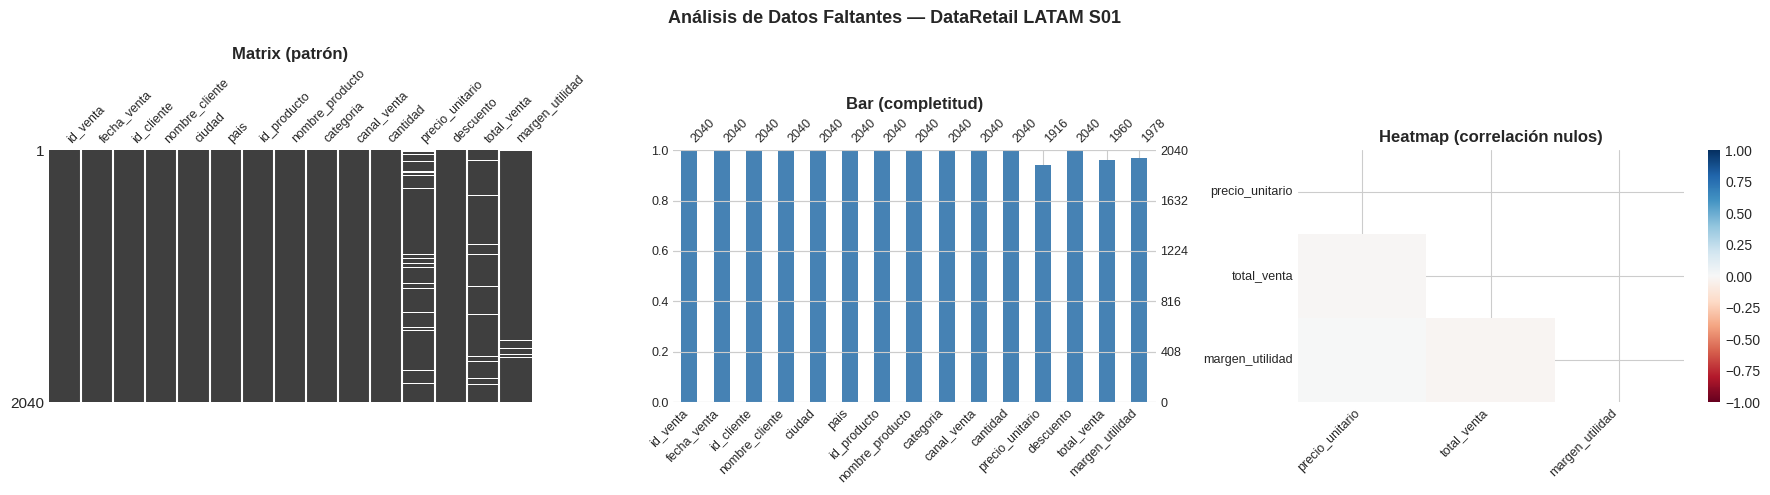

In [14]:
# 3 gráficos missingno
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Análisis de Datos Faltantes — DataRetail LATAM S01', fontsize=13, fontweight='bold')
msno.matrix(df, ax=axes[0], fontsize=9)
axes[0].set_title('Matrix (patrón)', fontweight='bold')
msno.bar(df, ax=axes[1], color='steelblue', fontsize=9)
axes[1].set_title('Bar (completitud)', fontweight='bold')
msno.heatmap(df, ax=axes[2], fontsize=9)
axes[2].set_title('Heatmap (correlación nulos)', fontweight='bold')
plt.tight_layout()
plt.show()

### 📝 Clasificación de Mecanismos de Nulos

> Clasifique cada columna con nulos:

| Columna | % Nulos | Mecanismo (MCAR/MAR/MNAR) | Justificación |
|---------|---------|--------------------------|---------------|
| precio_unitario | | | |
| total_venta | | | |
| margen_utilidad | | | |

## Parte 8 — Detección de Duplicados

Analice duplicados exactos y por `id_venta`. Muestre ejemplos.

In [15]:
n_dup_exacto = df.duplicated().sum()
n_dup_id     = df.duplicated(subset=['id_venta']).sum()

print(f'Registros totales:      {len(df):,}')
print(f'Duplicados exactos:     {n_dup_exacto:,} ({n_dup_exacto/len(df)*100:.2f}%)')
print(f'Duplicados id_venta:    {n_dup_id:,} ({n_dup_id/len(df)*100:.2f}%)')

if n_dup_exacto > 0:
    print('\nEjemplos:')
    mask = df.duplicated(keep=False)
    print(df[mask].sort_values('id_venta')[['id_venta','fecha_venta','nombre_producto','total_venta']].head(6).to_string())

Registros totales:      2,040
Duplicados exactos:     39 (1.91%)
Duplicados id_venta:    40 (1.96%)

Ejemplos:
     id_venta fecha_venta      nombre_producto  total_venta
741    V00019  2024-03-13  Teclado Inalámbrico       571.36
34     V00019  2024-03-13  Teclado Inalámbrico       571.36
1597   V00041  2025-02-13              SSD 1TB      1248.78
1888   V00041  2025-02-13              SSD 1TB      1248.78
304    V00074  2024-08-24    Smartphone Galaxy      6761.25
425    V00074  2024-08-24    Smartphone Galaxy      6761.25


## Parte 9 — Outliers con IQR y Z-score

In [16]:
# Tabla IQR
resultados_iqr = []
for col in cols_num:
    s = df[col].dropna()
    Q1, Q3 = s.quantile(.25), s.quantile(.75)
    IQR = Q3-Q1
    n_out = ((s < Q1-1.5*IQR)|(s > Q3+1.5*IQR)).sum()
    resultados_iqr.append({'Variable':col,'Q1':round(Q1,2),'Q3':round(Q3,2),
                           'IQR':round(IQR,2),'Outliers':n_out,'%':round(n_out/len(s)*100,2)})
print('TABLA IQR:')
print(pd.DataFrame(resultados_iqr).to_string(index=False))

TABLA IQR:
       Variable     Q1      Q3     IQR  Outliers     %
       cantidad   6.00   15.00    9.00         0  0.00
precio_unitario  96.77  494.04  397.27        98  5.11
      descuento   0.00    0.30    0.30         0  0.00
    total_venta 689.98 3920.64 3230.66       160  8.16
margen_utilidad  39.21  487.01  447.80       211 10.67


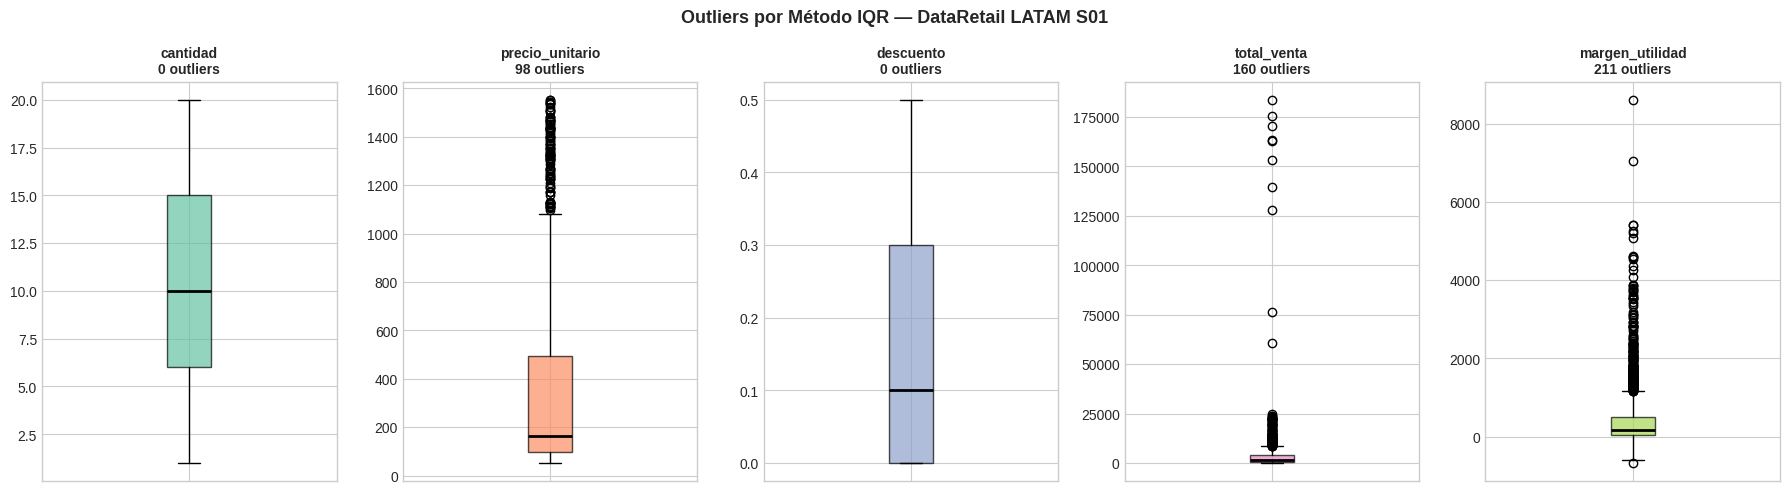

In [17]:
# Boxplots
fig, axes = plt.subplots(1, len(cols_num), figsize=(18, 5))
fig.suptitle('Outliers por Método IQR — DataRetail LATAM S01', fontsize=13, fontweight='bold')
for ax, col, c in zip(axes, cols_num, sns.color_palette('Set2',5)):
    s = df[col].dropna()
    Q1,Q3 = s.quantile(.25),s.quantile(.75)
    n_out = ((s < Q1-1.5*(Q3-Q1))|(s > Q3+1.5*(Q3-Q1))).sum()
    ax.boxplot(s, patch_artist=True, boxprops=dict(facecolor=c,alpha=0.7),
               medianprops=dict(color='black',linewidth=2))
    ax.set_title(f'{col}\n{n_out} outliers', fontweight='bold', fontsize=10)
    ax.tick_params(labelbottom=False)
plt.tight_layout(); plt.show()

In [18]:
# Z-score
print('OUTLIERS Z-SCORE (|Z|>3):')
for col in cols_num:
    s = df[col].dropna()
    z = np.abs(stats.zscore(s))
    print(f'  {col:20s}: {(z>3).sum():4d} outliers | máx valor = {s.max():,.2f}')

OUTLIERS Z-SCORE (|Z|>3):
  cantidad            :    0 outliers | máx valor = 20.00
  precio_unitario     :   55 outliers | máx valor = 1,552.63
  descuento           :    0 outliers | máx valor = 0.50
  total_venta         :   10 outliers | máx valor = 183,611.84
  margen_utilidad     :   47 outliers | máx valor = 8,606.14


### 📝 Clasificación de Outliers

> Para cada variable, clasifique los outliers:

| Variable | N° Outliers IQR | Clasificación | Justificación |
|----------|-----------------|---------------|---------------|
| cantidad | | | |
| precio_unitario | | | |
| total_venta | | | |
| descuento | | | |
| margen_utilidad | | | |

## Parte 10 — Inconsistencias Categóricas

In [19]:
cols_cat = ['ciudad','pais','categoria','canal_venta']
for col in cols_cat:
    vals = df[col].dropna()
    n_real  = vals.nunique()
    n_norm  = len(set(vals.str.strip().str.lower()))
    n_esp   = (vals != vals.str.strip()).sum()
    estado  = '⚠' if n_real > n_norm or n_esp > 0 else '✅'
    print(f'{estado} {col}: {n_real} únicos reales → {n_norm} normalizados | {n_esp} con espacios')
    if n_real > n_norm:
        print(f'   Muestra de valores:')
        print(f'   {list(vals.unique()[:8])}')
    print()

⚠ ciudad: 18 únicos reales → 13 normalizados | 18 con espacios
   Muestra de valores:
   ['bogota', 'Cali', 'Cartagena', 'Buenos Aires', 'Montevideo', 'Lima', 'Santiago', 'Barranquilla']

✅ pais: 6 únicos reales → 6 normalizados | 0 con espacios

✅ categoria: 7 únicos reales → 7 normalizados | 0 con espacios

⚠ canal_venta: 9 únicos reales → 7 normalizados | 16 con espacios
   Muestra de valores:
   ['E-commerce', 'Corporativo', 'Tienda Física', 'Distribuidor', 'Marketplace', 'tienda fisica', 'E-Comerce', 'CORPORATIVO']



## Parte 11 — Validación de Dominio

In [20]:
reglas = [
    ('descuento <= 0.30',  df['descuento'] > 0.30),
    ('precio_unitario > 0', df['precio_unitario'] <= 0),
    ('total_venta > 0',    df['total_venta'] <= 0),
    ('cantidad >= 1',      df['cantidad'] < 1),
    ('fecha 2024-2025',    ~df['fecha_venta'].between('2024-01-01','2025-12-31')),
]
print('VALIDACIÓN DE REGLAS DE NEGOCIO:')
print('='*55)
for regla, cond in reglas:
    try:
        n = cond.sum()
        estado = '⚠️' if n > 0 else '✅'
        print(f'{estado} {regla:30s}: {n:,} violaciones ({n/len(df)*100:.2f}%)')
    except Exception as e:
        print(f'  Error en {regla}: {e}')

VALIDACIÓN DE REGLAS DE NEGOCIO:
⚠️ descuento <= 0.30             : 415 violaciones (20.34%)
✅ precio_unitario > 0           : 0 violaciones (0.00%)
✅ total_venta > 0               : 0 violaciones (0.00%)
✅ cantidad >= 1                 : 0 violaciones (0.00%)
✅ fecha 2024-2025               : 0 violaciones (0.00%)


## Parte 12 — Panel Visual de Calidad

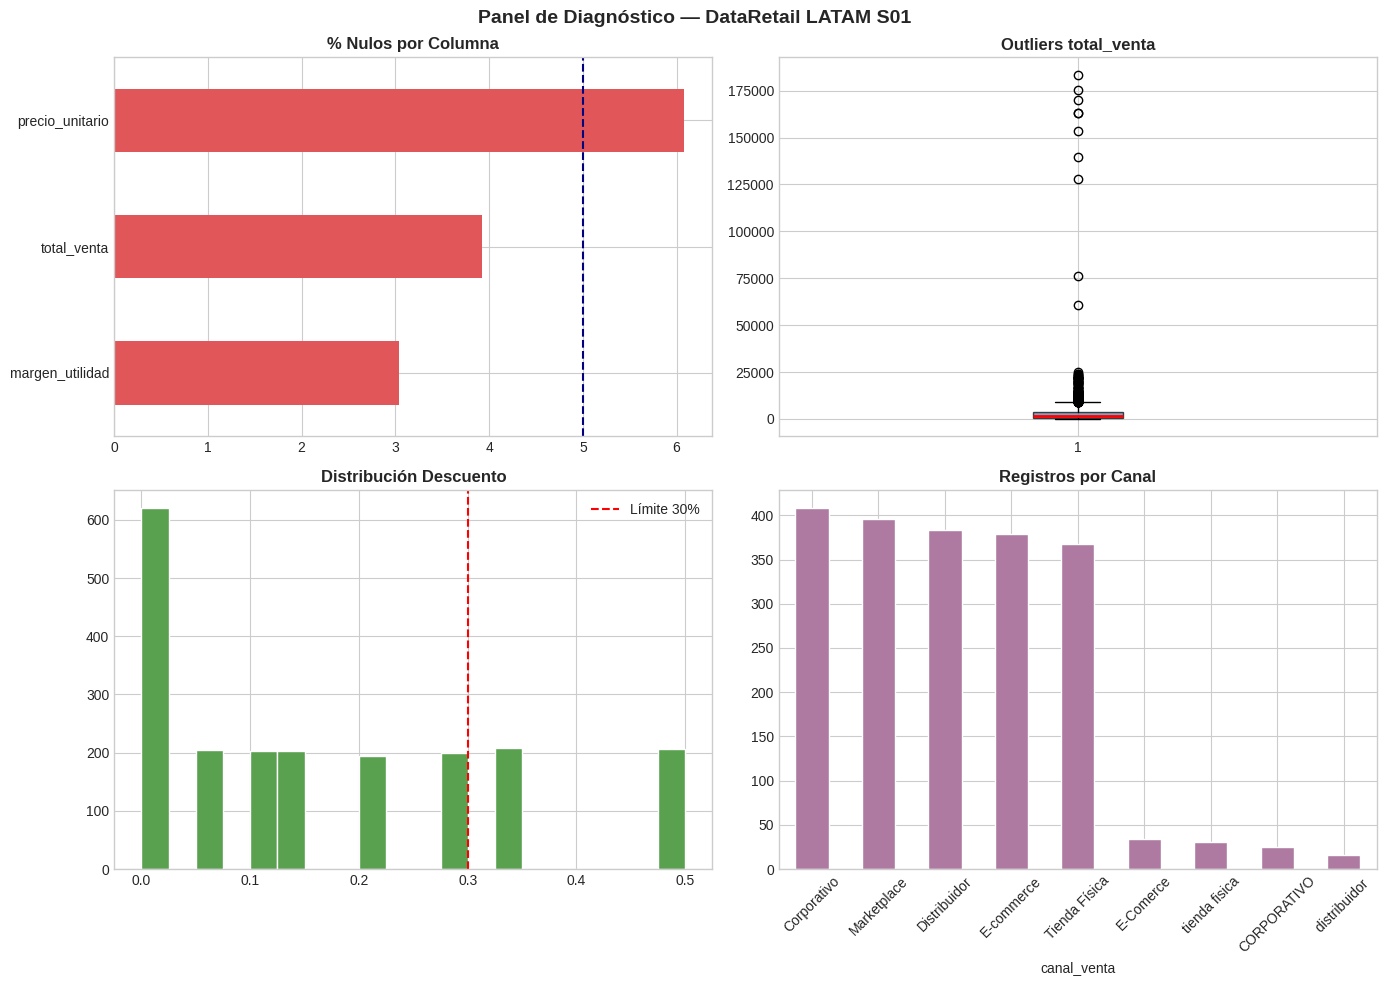

In [21]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Panel de Diagnóstico — DataRetail LATAM S01', fontsize=14, fontweight='bold')

# 1. Nulos por columna
pct_n = df.isna().mean()*100
pct_n = pct_n[pct_n>0].sort_values()
if len(pct_n):
    pct_n.plot(kind='barh', ax=axes[0,0], color='#e15759')
    axes[0,0].set_title('% Nulos por Columna', fontweight='bold')
    axes[0,0].axvline(5, color='navy', linestyle='--')

# 2. Boxplot total_venta
axes[0,1].boxplot(df['total_venta'].dropna(), patch_artist=True,
                   boxprops=dict(facecolor='#4e79a7',alpha=0.7),
                   medianprops=dict(color='red',linewidth=2))
axes[0,1].set_title('Outliers total_venta', fontweight='bold')

# 3. Distribución descuento
df['descuento'].dropna().hist(ax=axes[1,0], bins=20, color='#59a14f', edgecolor='white')
axes[1,0].axvline(0.30, color='red', linestyle='--', label='Límite 30%')
axes[1,0].set_title('Distribución Descuento', fontweight='bold')
axes[1,0].legend()

# 4. Canal de venta
df['canal_venta'].value_counts().plot(kind='bar', ax=axes[1,1], color='#af7aa1', edgecolor='white')
axes[1,1].set_title('Registros por Canal', fontweight='bold')
axes[1,1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

## Parte 13 — Score de Calidad y Reporte Final

Calcule el score de calidad y construya el reporte diagnóstico para el CTO.

In [22]:
# Score de calidad
pct_nulos_g  = df.isna().mean().mean()*100
pct_dup      = df.duplicated().mean()*100
s_tv = df['total_venta'].dropna()
Q1,Q3 = s_tv.quantile(.25), s_tv.quantile(.75)
pct_out      = ((s_tv < Q1-1.5*(Q3-Q1))|(s_tv > Q3+1.5*(Q3-Q1))).mean()*100
pct_desc_viol= (df['descuento'] > 0.30).mean()*100

score = 100
score -= min(pct_nulos_g * 3, 30)
score -= min(pct_dup * 5, 20)
score -= min(pct_out * 1.5, 15)
score -= min(pct_desc_viol * 2, 10)
nivel = '🔴 CRÍTICO' if score<60 else ('🟠 BAJO' if score<75 else ('🟡 ACEPTABLE' if score<90 else '🟢 BUENO'))

print('='*60)
print('  REPORTE DIAGNÓSTICO — DataRetail LATAM S01')
print('='*60)
print(f'  % Nulos globales:        {pct_nulos_g:.2f}%')
print(f'  % Duplicados:            {pct_dup:.2f}%')
print(f'  % Outliers total_venta:  {pct_out:.2f}%')
print(f'  % Violac. descuento:     {pct_desc_viol:.2f}%')
print(f'  SCORE:  {score:.1f}/100  {nivel}')
print('='*60)

  REPORTE DIAGNÓSTICO — DataRetail LATAM S01
  % Nulos globales:        0.87%
  % Duplicados:            1.91%
  % Outliers total_venta:  8.16%
  % Violac. descuento:     20.34%
  SCORE:  65.6/100  🟠 BAJO


### 📝 Plan de Acción para S02

> Complete la tabla con sus hallazgos reales:

| Prioridad | Problema | Columnas | Acción en S02 |
|-----------|----------|----------|---------------|
| 1 | Nulos MCAR | | |
| 2 | Nulos MAR | | |
| 3 | Duplicados | id_venta | drop_duplicates |
| 4 | Outliers extremos | | |
| 5 | Inconsistencias | ciudad, canal_venta | str.strip().str.title() |
| 6 | Violaciones dominio | descuento | Cap a 0.30 |

### 💡 Insights de Negocio (mínimo 3)

> En lenguaje ejecutivo para el CTO:

1. **[Título]:** [Descripción del impacto en el negocio...]

2. **[Título]:** [Descripción del impacto en el negocio...]

3. **[Título]:** [Descripción del impacto en el negocio...]

## Referencias

1. McKinney, W. (2022). *Python for Data Analysis* (3.ª ed.). O'Reilly Media.
2. Little, R. & Rubin, D. (2019). *Statistical Analysis with Missing Data* (3.ª ed.). Wiley.
3. Bilogur, A. (2023). missingno. https://github.com/ResidentMario/missingno
4. VanderPlas, J. (2023). *Python Data Science Handbook*. O'Reilly.
5. ydata-profiling (2024). https://docs.profiling.ydata.ai

---
*Notebook Actividad S01 — Diplomado de Grado en Análisis de Datos Aplicado a la Toma de Decisiones  
UNICOLOMBO · Cartagena · Docente: Ing. Heyder Medrano Olier · 2026*